<a href="https://colab.research.google.com/github/amit-singh-tech/AirBnb-Booking-Analysis/blob/main/face_mask_detection_using_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


# **importing face mask dataset**

In [4]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 244MB/s]



In [5]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
!ls

data  face-mask-dataset.zip  sample_data


# **Importing the dependencies**

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [10]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1224.jpg', 'with_mask_3001.jpg', 'with_mask_2586.jpg', 'with_mask_1653.jpg', 'with_mask_2675.jpg']
['with_mask_311.jpg', 'with_mask_3276.jpg', 'with_mask_1659.jpg', 'with_mask_2531.jpg', 'with_mask_69.jpg']


In [11]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_226.jpg', 'without_mask_3326.jpg', 'without_mask_1347.jpg', 'without_mask_1410.jpg', 'without_mask_992.jpg']
['without_mask_2311.jpg', 'without_mask_965.jpg', 'without_mask_3021.jpg', 'without_mask_380.jpg', 'without_mask_668.jpg']


In [12]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


# **Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [13]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [14]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [15]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [16]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


# **Displaying the Images**

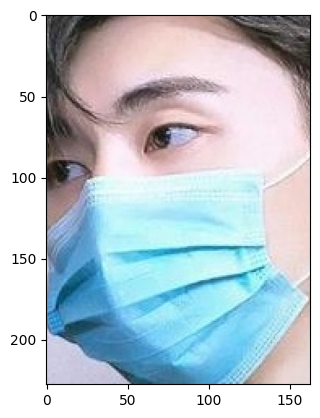

In [17]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

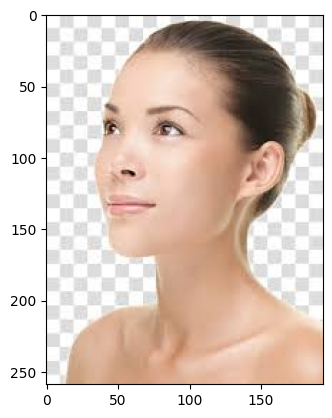

In [18]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

 **Image processing**

Resize the Images

Convert the images to numpy arrays

In [19]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [20]:
type(data)

list

In [21]:
len(data)

7553

array([[[18, 10,  8],
        [17, 11,  8],
        [15, 10,  9],
        ...,
        [26, 19, 10],
        [28, 21, 13],
        [30, 23, 15]],

       [[17,  9,  7],
        [15,  9,  6],
        [14, 10,  8],
        ...,
        [24, 17,  9],
        [27, 20, 12],
        [28, 21, 13]],

       [[15, 10,  6],
        [13,  8,  4],
        [13,  8,  5],
        ...,
        [23, 16,  8],
        [25, 18, 10],
        [26, 19, 11]],

       ...,

       [[19, 14, 11],
        [18, 12,  7],
        [16,  6,  1],
        ...,
        [15, 10,  6],
        [17, 11,  8],
        [20, 12,  9]],

       [[17, 12,  8],
        [18, 12,  7],
        [20, 10,  4],
        ...,
        [16, 11,  7],
        [18, 12,  8],
        [20, 12,  9]],

       [[16, 11,  7],
        [18, 12,  6],
        [22, 12,  6],
        ...,
        [16, 11,  7],
        [18, 12,  9],
        [21, 13, 10]]], dtype=uint8)
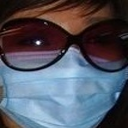

In [23]:
data[0]

In [24]:
type(data[0])

numpy.ndarray

In [25]:
data[0].shape

(128, 128, 3)

In [26]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [27]:
type(X)

numpy.ndarray

In [28]:
type(Y)

numpy.ndarray

In [29]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [30]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [32]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [33]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[ 64,  53,  47],
        [ 57,  46,  40],
        [ 57,  46,  42],
        ...,
        [229, 210, 205],
        [229, 210, 203],
        [230, 211, 204]],

       [[ 58,  47,  41],
        [ 59,  48,  42],
        [ 59,  48,  44],
        ...,
        [235, 216, 210],
        [230, 211, 204],
        [233, 214, 207]],

       [[ 63,  52,  46],
        [ 63,  52,  46],
        [ 64,  53,  48],
        ...,
        [224, 205, 198],
        [227, 208, 201],
        [232, 213, 206]],

       ...,

       [[249, 230, 212],
        [249, 230, 212],
        [250, 231, 213],
        ...,
        [248, 233, 217],
        [250, 234, 218],
        [250, 235, 218]],

       [[249, 231, 211],
        [249, 231, 211],
        [249, 231, 211],
        ...,
        [244, 232, 217],
        [246, 232, 219],
        [245, 233, 219]],

       [[248, 230, 209],
        [249, 231, 209],
        [248, 230, 210],
        ...,
        [238, 228, 217],
        [237, 227, 218],
        [235, 225, 215]]], dtype=uint8)
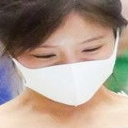

In [34]:
X_train[0]

In [35]:
X_train_scaled[0]

array([[[0.25098039, 0.20784314, 0.18431373],
        [0.22352941, 0.18039216, 0.15686275],
        [0.22352941, 0.18039216, 0.16470588],
        ...,
        [0.89803922, 0.82352941, 0.80392157],
        [0.89803922, 0.82352941, 0.79607843],
        [0.90196078, 0.82745098, 0.8       ]],

       [[0.22745098, 0.18431373, 0.16078431],
        [0.23137255, 0.18823529, 0.16470588],
        [0.23137255, 0.18823529, 0.17254902],
        ...,
        [0.92156863, 0.84705882, 0.82352941],
        [0.90196078, 0.82745098, 0.8       ],
        [0.91372549, 0.83921569, 0.81176471]],

       [[0.24705882, 0.20392157, 0.18039216],
        [0.24705882, 0.20392157, 0.18039216],
        [0.25098039, 0.20784314, 0.18823529],
        ...,
        [0.87843137, 0.80392157, 0.77647059],
        [0.89019608, 0.81568627, 0.78823529],
        [0.90980392, 0.83529412, 0.80784314]],

       ...,

       [[0.97647059, 0.90196078, 0.83137255],
        [0.97647059, 0.90196078, 0.83137255],
        [0.98039216, 0

**Building a Convolutional Neural Networks (CNN)**

In [36]:
import tensorflow as tf
from tensorflow import keras

In [37]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [39]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 169s 976ms/step - acc: 0.8135 - loss: 0.4426 - val_acc: 0.8496 - val_loss: 0.3317
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 163s 958ms/step - acc: 0.8928 - loss: 0.2784 - val_acc: 0.8926 - val_loss: 0.2405
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 198s 935ms/step - acc: 0.9055 - loss: 0.2299 - val_acc: 0.9174 - val_loss: 0.2257
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 150s 883ms/step - acc: 0.9215 - loss: 0.1916 - val_acc: 0.9223 - val_loss: 0.2076
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 155s 913ms/step - acc: 0.9351 - loss: 0.1630 - val_acc: 0.9223 - val_loss: 0.2673


# **Model Evaluation**

In [40]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 222ms/step - acc: 0.9153 - loss: 0.2541
Test Accuracy = 0.9152879118919373


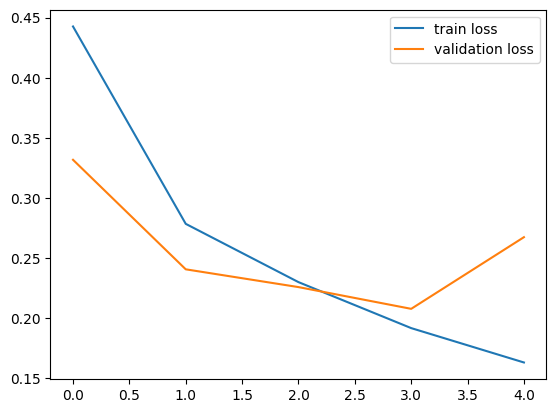

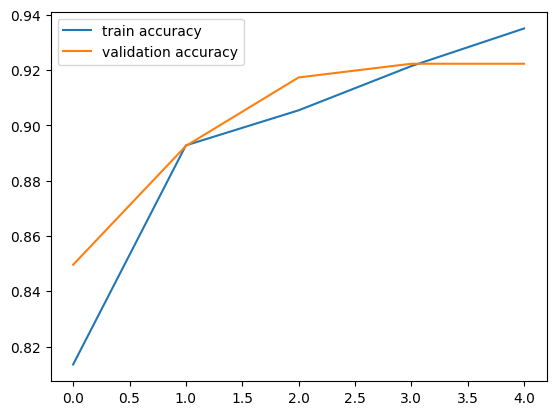

In [41]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

# **Predictive System**

Path of the image to be predicted: /content/asas.png


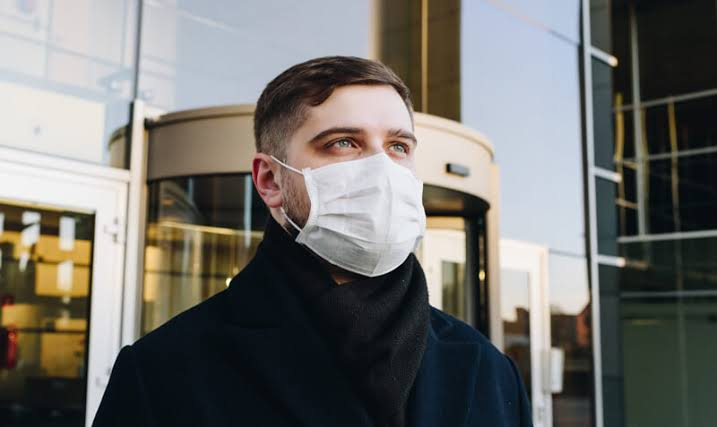

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[0.14248957 0.7898147 ]]
1
The person in the image is wearing a mask


In [45]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/test.jpg


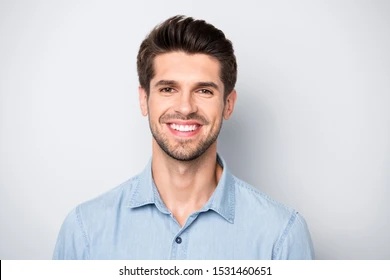

1/1 [==============================] - 0s 21ms/step
[[0.49811754 0.47740024]]
0
The person in the image is not wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')